In [2]:
from warnings import simplefilter
simplefilter(action='ignore')
import numpy as np 
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns 
import scienceplots
plt.style.use('seaborn-v0_8')
# plt.rcParams['text.usetex'] = True
# plt.rcParams['font.family'] = 'serif'  
# plt.rcParams['font.serif'] = ['Computer Modern']
# plt.rcParams['font.size'] = 12

In [3]:
house = pd.read_parquet("house_clean.parquet")

In [4]:
house.head()

,cand_id,cycle,state,district,cand_name_first,cand_name_last,cand_name,incumbency,outcome,unopposed,...,ttl_indiv_contrib,other_pol_cmte_contrib,pol_pty_contrib,log1p_ttl_receipts,burn_rate,cash_ratio,indiv_share,other_cmte_share,party_share,party
0,H6AK00045,2004,AK,0,Alvin A.,Anders,"YOUNG, DON E",I,0,False,...,1491130.73,928658.63,392.0,14.724952,0.703966,0.764646,0.600552,0.374016,0.000158,OTH
1,H2AL01119,2004,AL,1,Judy,Belk,"BELK, JUDY MCCAIN",C,0,False,...,124177.72,74430.20,14050.0,13.050812,1.138603,0.000942,0.266777,0.159902,0.030184,DEM
2,H2AL01077,2004,AL,1,Jo,Bonner,"BONNER, JOSIAH ROBINS JR.",I,1,False,...,778293.95,394355.71,750.0,13.981784,0.860118,0.150955,0.659071,0.333946,0.000635,REP
3,H2AL02067,2004,AL,2,Terry,Everett,"EVERETT, TERRY",I,1,False,...,439265.74,336616.98,6036.3,14.509380,0.967823,0.140757,0.219474,0.168187,0.003016,REP
4,H4AL03046,2004,AL,3,Bill,Fuller,"FULLER, BILL",C,0,False,...,162038.21,115700.00,2500.0,12.543399,0.859185,0.107983,0.578216,0.412863,0.008921,DEM


In [5]:
inc_map = {'I': 'Incumbent', 'C': 'Challenger', 'O': 'Open'}

inc = house['incumbency'].map(inc_map).fillna('Unknown')

n = len(house)
winners = (house['outcome'] == 1).sum()
losers = (house['outcome'] == 0).sum()

vote_share = house['vote_share'].dropna()
receipts = house['ttl_receipts'].dropna()

def pct(x, denom=n):
    return f'{100 * x / denom:.1f}%'

def money(x):
    return f'${x:,.0f}'

sample = pd.DataFrame({
    'Metric': ['Election cycles', 'Jurisdictions represented', 'Candidate observations', 'Winners', 'Losers', 'Incumbents', 'Challengers', 'Open-seat contenders',
        'Median vote share [IQR]', 'Median total receipts [IQR]'],
    'Value': [
        f'{int(house['cycle'].min())}–{int(house['cycle'].max())}',
        f'{house['state'].nunique():,}',
        f'{n:,}',
        f'{winners:,} ({pct(winners)})',
        f'{losers:,} ({pct(losers)})',
        f'{(inc == 'Incumbent').sum():,} ({pct((inc == 'Incumbent').sum())})',
        f'{(inc == 'Challenger').sum():,} ({pct((inc == 'Challenger').sum())})',
        f'{(inc == 'Open').sum():,} ({pct((inc == 'Open').sum())})',
        (
            f'{100 * vote_share.median():.1f}% '
            f'[{100 * vote_share.quantile(0.25):.1f}%, {100 * vote_share.quantile(0.75):.1f}%]'
        ),
        (
            f'{money(receipts.median())} '
            f'[{money(receipts.quantile(0.25))}, {money(receipts.quantile(0.75))}]'
        )
    ]
})

unknown_n = (inc == 'Unknown').sum()
if unknown_n > 0:
    sample.loc[len(sample)] = [
        'Unknown incumbency code',
        f'{unknown_n:,} ({pct(unknown_n)})'
    ]

print('Table 1. Analytic Sample Overview')
display(sample)
sample.to_csv('Table_1.csv')

Table 1. Analytic Sample Overview


,Metric,Value
0,Election cycles,2004–2022
1,Jurisdictions represented,56
2,Candidate observations,"8,129"
3,Winners,"4,206 (51.7%)"
4,Losers,"3,923 (48.3%)"
5,Incumbents,"3,757 (46.2%)"
6,Challengers,"3,446 (42.4%)"
7,Open-seat contenders,926 (11.4%)
8,Median vote share [IQR],"50.5% [35.6%, 64.2%]"
9,Median total receipts [IQR],"$923,140 [$138,925, $1,717,516]"


In [6]:
vars_for_desc = {
    'vote_share': 'General vote share',
    'ttl_receipts': 'Total receipts (USD)',
    'ttl_disb': 'Total disbursements (USD)',
    'coh_cop': 'Cash on hand (USD)',
    'log1p_ttl_receipts': 'ln(1 + total receipts)',
    'burn_rate': 'Burn rate',
    'cash_ratio': 'Cash ratio',
    'indiv_share': 'Individual contribution share',
    'other_cmte_share': 'Other committee contribution share',
    'party_share': 'Party contribution share'}

desc = (house[list(vars_for_desc)].agg(['count', 'mean', 'std', 'median', 'min', 'max']).T)

quartiles = house[list(vars_for_desc)].quantile([0.25, 0.75]).T
quartiles.columns = ['Q1', 'Q3']

desc = (desc.join(quartiles).rename(columns={'count': 'N', 'mean': 'Mean', 'std': 'SD', 'median': 'Median', 'min': 'Min', 'max': 'Max'}
                                        ).loc[:, ['N', 'Mean', 'SD', 'Median', 'Q1', 'Q3', 'Min', 'Max']])

desc.index = [vars_for_desc[col] for col in desc.index]
desc = desc.reset_index().rename(columns={'index': 'Variable'})

money_rows = {'Total receipts (USD)', 'Total disbursements (USD)', 'Cash on hand (USD)'}

for col in ['Mean', 'SD', 'Median', 'Q1', 'Q3', 'Min', 'Max']:
    desc[col] = desc.apply(lambda row: f"${row[col]:,.0f}" if row['Variable'] in money_rows else f"{row[col]:.3f}", axis=1)

print('Table 2. Descriptive Statistics for Key Features')
display(desc)
desc.to_csv('Table_2.csv')

Table 2. Descriptive Statistics for Key Features


,Variable,N,Mean,SD,Median,Q1,Q3,Min,Max
0,General vote share,8129.0,0.491,0.211,0.505,0.356,0.642,0.000,0.999
1,Total receipts (USD),8129.0,"$1,295,907","$1,825,149","$923,140","$138,925","$1,717,516","$5,000","$38,160,642"
2,Total disbursements (USD),8129.0,"$1,229,883","$1,734,361","$824,502","$133,963","$1,618,680","$-1,632","$33,728,421"
3,Cash on hand (USD),8129.0,"$269,590","$676,106","$29,796","$1,560","$264,512","$-71,198","$21,022,960"
4,ln(1 + total receipts),8129.0,13.084,1.794,13.736,11.842,14.356,8.517,17.457
5,Burn rate,8129.0,0.952,0.160,0.986,0.908,1.000,0.417,1.505
6,Cash ratio,8129.0,0.191,0.313,0.042,0.006,0.247,-0.058,1.610
7,Individual contribution share,8129.0,0.587,0.242,0.586,0.414,0.785,0.013,1.000
8,Other committee contribution share,8129.0,0.264,0.234,0.219,0.034,0.459,0.000,0.792
9,Party contribution share,8129.0,0.008,0.027,0.000,0.000,0.003,0.000,0.186


In [7]:

vars_for_differences = {
    'vote_share': 'General vote share',
    'ttl_receipts': 'Total receipts (USD)',
    'ttl_disb': 'Total disbursements (USD)',
    'coh_cop': 'Cash on hand (USD)',
    'log1p_ttl_receipts': 'ln(1 + total receipts)',
    'burn_rate': 'Burn rate',
    'cash_ratio': 'Cash ratio',
    'indiv_share': 'Individual contribution share',
    'other_cmte_share': 'Other committee contribution share',
    'party_share': 'Party contribution share'
}

money_rows = {'Total receipts (USD)', 'Total disbursements (USD)', 'Cash on hand (USD)'}

rows = []
for col, label in vars_for_differences.items():
    winners = house.loc[house['outcome'] == 1, col].dropna()
    losers = house.loc[house['outcome'] == 0, col].dropna()
    pval = stats.ttest_ind(winners, losers, equal_var=False, nan_policy='omit').pvalue
    rows.append({
        'Variable': label,
        'Winner N': len(winners),
        'Loser N': len(losers),
        'Winner Mean': winners.mean(),
        'Loser Mean': losers.mean(),
        'Difference': winners.mean() - losers.mean(),
        'p-value': pval
    })

differences = pd.DataFrame(rows)

for col in ['Winner N', 'Loser N']:
    differences[col] = differences[col].astype(int)

for col in ['Winner Mean', 'Loser Mean', 'Difference']:
    differences[col] = differences.apply(lambda row: f"${row[col]:,.0f}" if row['Variable'] in money_rows else f"{row[col]:.3f}", axis=1)

differences['p-value'] = differences['p-value'].map(lambda x: '<0.001' if x < 0.001 else f'{x:.3f}')

print('Table 3. Mean Differences in Key Features by Electoral Outcome')
display(differences)
differences.to_csv('Table_3.csv')

Table 3. Mean Differences in Key Features by Electoral Outcome


,Variable,Winner N,Loser N,Winner Mean,Loser Mean,Difference,p-value
0,General vote share,4206,3923,0.654,0.317,0.337,<0.001
1,Total receipts (USD),4206,3923,"$1,831,428","$721,754","$1,109,674",<0.001
2,Total disbursements (USD),4206,3923,"$1,705,488","$719,969","$985,519",<0.001
3,Cash on hand (USD),4206,3923,"$506,880","$15,183","$491,697",<0.001
4,ln(1 + total receipts),4206,3923,14.142,11.949,2.193,<0.001
5,Burn rate,4206,3923,0.931,0.974,-0.043,<0.001
6,Cash ratio,4206,3923,0.330,0.041,0.288,<0.001
7,Individual contribution share,4206,3923,0.521,0.658,-0.137,<0.001
8,Other committee contribution share,4206,3923,0.425,0.091,0.334,<0.001
9,Party contribution share,4206,3923,0.002,0.015,-0.013,<0.001


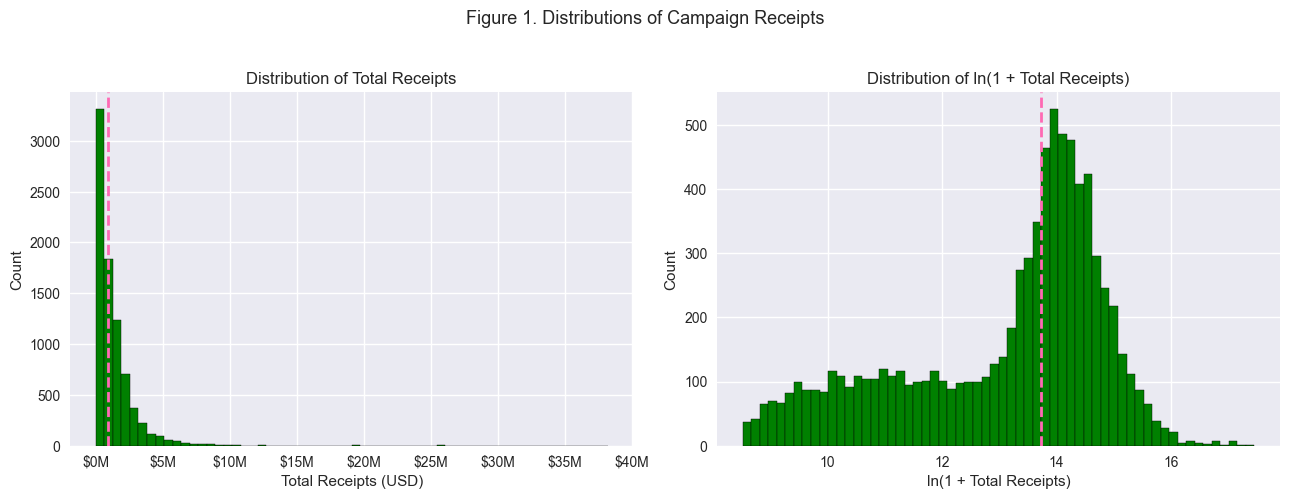

In [8]:
from matplotlib.ticker import FuncFormatter

receipts = house['ttl_receipts'].dropna()
log_receipts = house['log1p_ttl_receipts'].dropna()

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

ax[0].hist(receipts, bins=60, edgecolor='black', color='green')
ax[0].axvline(receipts.median(), linestyle='--', linewidth=2, color='#FF69B4')
ax[0].set_title('Distribution of Total Receipts')
ax[0].set_xlabel('Total Receipts (USD)')
ax[0].set_ylabel('Count')
ax[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))

ax[1].hist(log_receipts, bins=60, edgecolor='black', color='green')
ax[1].axvline(log_receipts.median(), linestyle='--', linewidth=2, color='#FF69B4')
ax[1].set_title('Distribution of ln(1 + Total Receipts)')
ax[1].set_xlabel('ln(1 + Total Receipts)')
ax[1].set_ylabel('Count')

plt.suptitle('Figure 1. Distributions of Campaign Receipts', y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

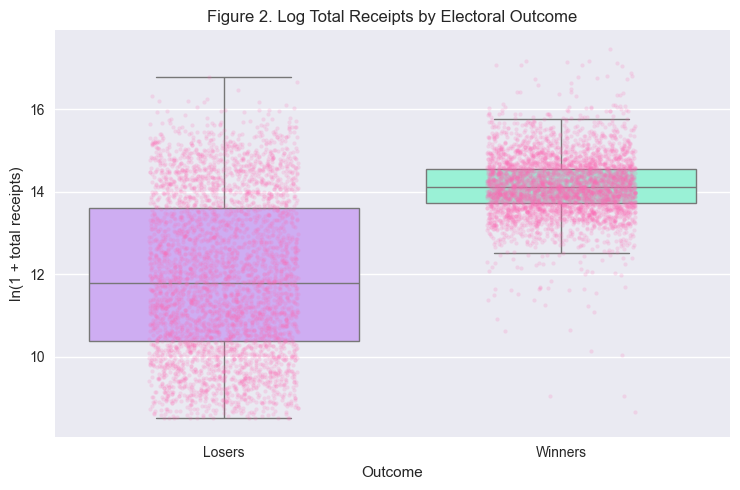

In [9]:
winner_vals = house.loc[house['outcome'] == 1, 'log1p_ttl_receipts'].dropna().to_numpy()
loser_vals = house.loc[house['outcome'] == 0, 'log1p_ttl_receipts'].dropna().to_numpy()

plot_df = house.loc[house['outcome'].isin([0, 1]), ['outcome', 'log1p_ttl_receipts']].copy()
plot_df['Outcome'] = plot_df['outcome'].map({0: 'Losers', 1: 'Winners'})

plt.figure(figsize=(7.5, 5))
sns.boxplot(data=plot_df, x='Outcome', y='log1p_ttl_receipts', palette=['#cea2fd', '#8cffdb'], showfliers=False)
sns.stripplot(data=plot_df, x='Outcome', y='log1p_ttl_receipts', color='#FF69B4', alpha=0.18, size=3, jitter=0.22)

plt.title('Figure 2. Log Total Receipts by Electoral Outcome')
plt.xlabel('Outcome')
plt.ylabel('ln(1 + total receipts)')
plt.tight_layout()
plt.show()

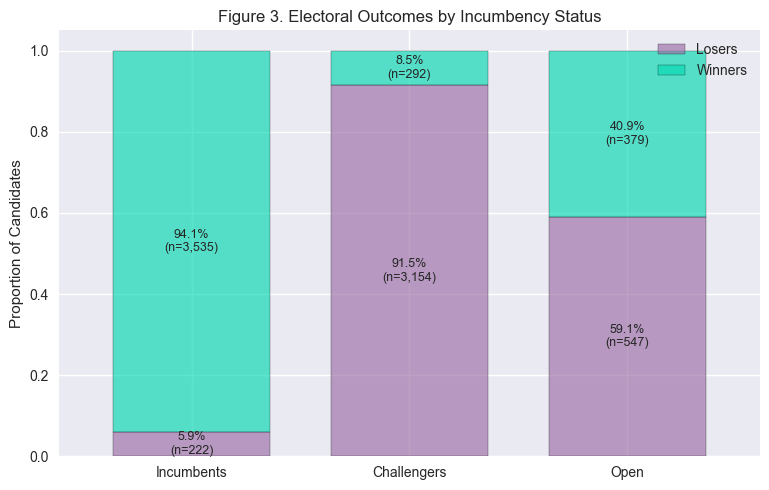

In [10]:
plot_df = house.loc[house['incumbency'].isin(['I', 'C', 'O']), ['incumbency', 'outcome']].copy()
plot_df['Incumbency status'] = plot_df['incumbency'].map({'I': 'Incumbents', 'C': 'Challengers', 'O': 'Open'})
plot_df['Outcome'] = plot_df['outcome'].map({0: 'Losers', 1: 'Winners'})

shares = pd.crosstab(plot_df['Incumbency status'], plot_df['Outcome'], normalize='index').reindex(['Incumbents', 'Challengers', 'Open'])
counts = pd.crosstab(plot_df['Incumbency status'], plot_df['Outcome']).reindex(['Incumbents', 'Challengers', 'Open'])

ax = shares[['Losers', 'Winners']].plot(kind='bar', stacked=True, figsize=(7.8, 5), color=['#9c6da5', '#04d8b2'], edgecolor='black', width=0.72, alpha=0.65)

for i, status in enumerate(shares.index):
    loser_share = shares.loc[status, 'Losers']
    winner_share = shares.loc[status, 'Winners']
    loser_n = counts.loc[status, 'Losers']
    winner_n = counts.loc[status, 'Winners']
    ax.text(i, loser_share / 2, f'{100 * loser_share:.1f}%\n(n={loser_n:,})', ha='center', va='center', fontsize=9)
    ax.text(i, loser_share + winner_share / 2, f'{100 * winner_share:.1f}%\n(n={winner_n:,})', ha='center', va='center', fontsize=9)

ax.set_title('Figure 3. Electoral Outcomes by Incumbency Status')
ax.set_xlabel('')
ax.set_ylabel('Proportion of Candidates')
ax.legend(title='')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

__Figure 3__ shows a strong association between incumbency and electoral outcome. Incumbents win far more often than challengers, whereas open-seat contenders appear roughly evenly split, affirming incumbency as one of the clearest structural correlates of electoral success in the sample.

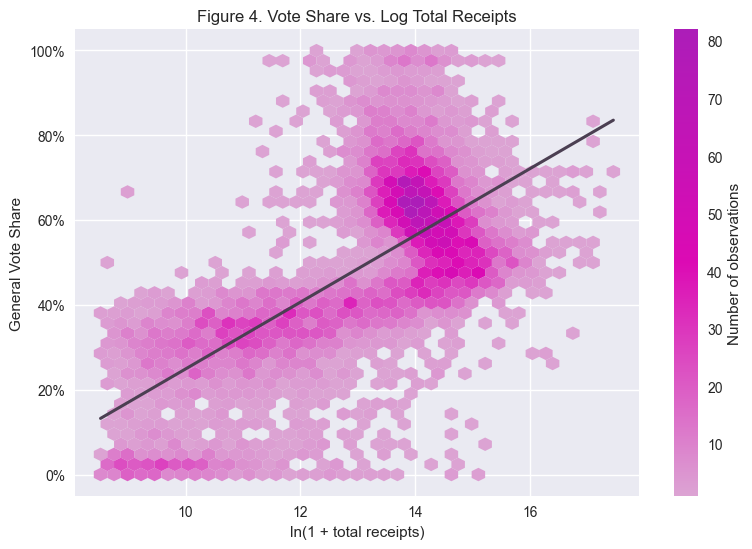

In [11]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mtick

plot_df = house[['log1p_ttl_receipts', 'vote_share']].dropna()

hex_cmap = LinearSegmentedColormap.from_list('campaign_hex', ['#dca3d3', '#dc0ab4', '#ac1db8'])

fig, ax = plt.subplots(figsize=(8, 5.6))

hb = ax.hexbin( plot_df['log1p_ttl_receipts'], plot_df['vote_share'], gridsize=38, cmap=hex_cmap, mincnt=1, linewidths=0 )

sns.regplot( data=plot_df, x='log1p_ttl_receipts', y='vote_share', scatter=False, ci=None, line_kws={'color': '#4b3f52', 'linewidth': 2.2}, ax=ax )

cbar = fig.colorbar(hb, ax=ax)
cbar.set_label('Number of observations')

ax.set_title('Figure 4. Vote Share vs. Log Total Receipts')
ax.set_xlabel('ln(1 + total receipts)')
ax.set_ylabel('General Vote Share')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

plt.tight_layout()
plt.show()

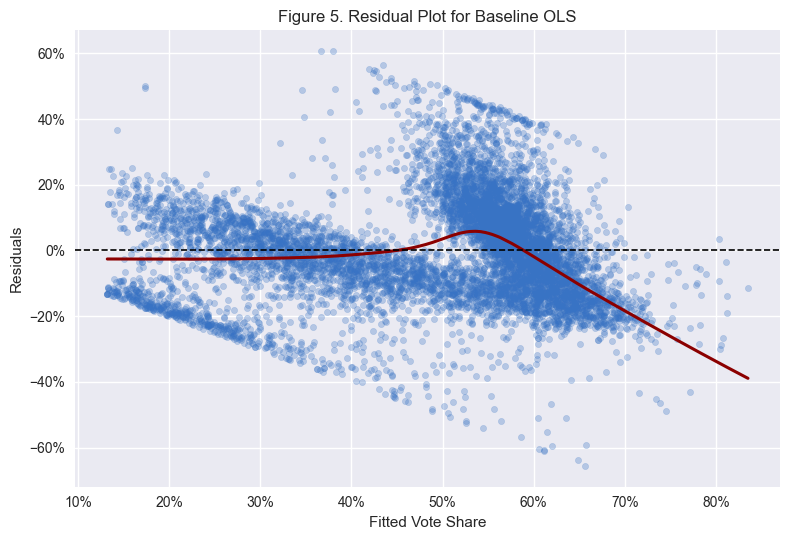

In [12]:
import matplotlib.ticker as mtick

ols_df = house[['vote_share', 'log1p_ttl_receipts']].dropna().copy()
X = sm.add_constant(ols_df['log1p_ttl_receipts'])
y = ols_df['vote_share']
model = sm.OLS(y, X).fit()

resid_df = pd.DataFrame({ 'Fitted Vote Share': model.fittedvalues, 'Residuals': model.resid })

plt.figure(figsize=(8, 5.5))

sns.scatterplot(data=resid_df, x='Fitted Vote Share', y='Residuals', color='#3873C4', alpha=0.3, s=20, edgecolor=None )

sns.regplot( data=resid_df, x='Fitted Vote Share', y='Residuals', lowess=True, scatter=False, ci=None, line_kws={'color': '#8B0000', 'linewidth': 2.2} )

plt.axhline(0, color='black', linestyle='--', linewidth=1.2)
plt.title('Figure 5. Residual Plot for Baseline OLS')
plt.xlabel('Fitted Vote Share')
plt.ylabel('Residuals')
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
plt.tight_layout()
plt.show()

__Figure 5__ The residual plot for the baseline regression of vote share on log total receipts reveals substantial structure remaining in the error. While the distinctive wedge-shaped pattern is mostly determined by the bounded nature of vote share, the visible curvature and variable dispersion indicate that campaign receipts alone do not fully capture observed variation in electoral performance.

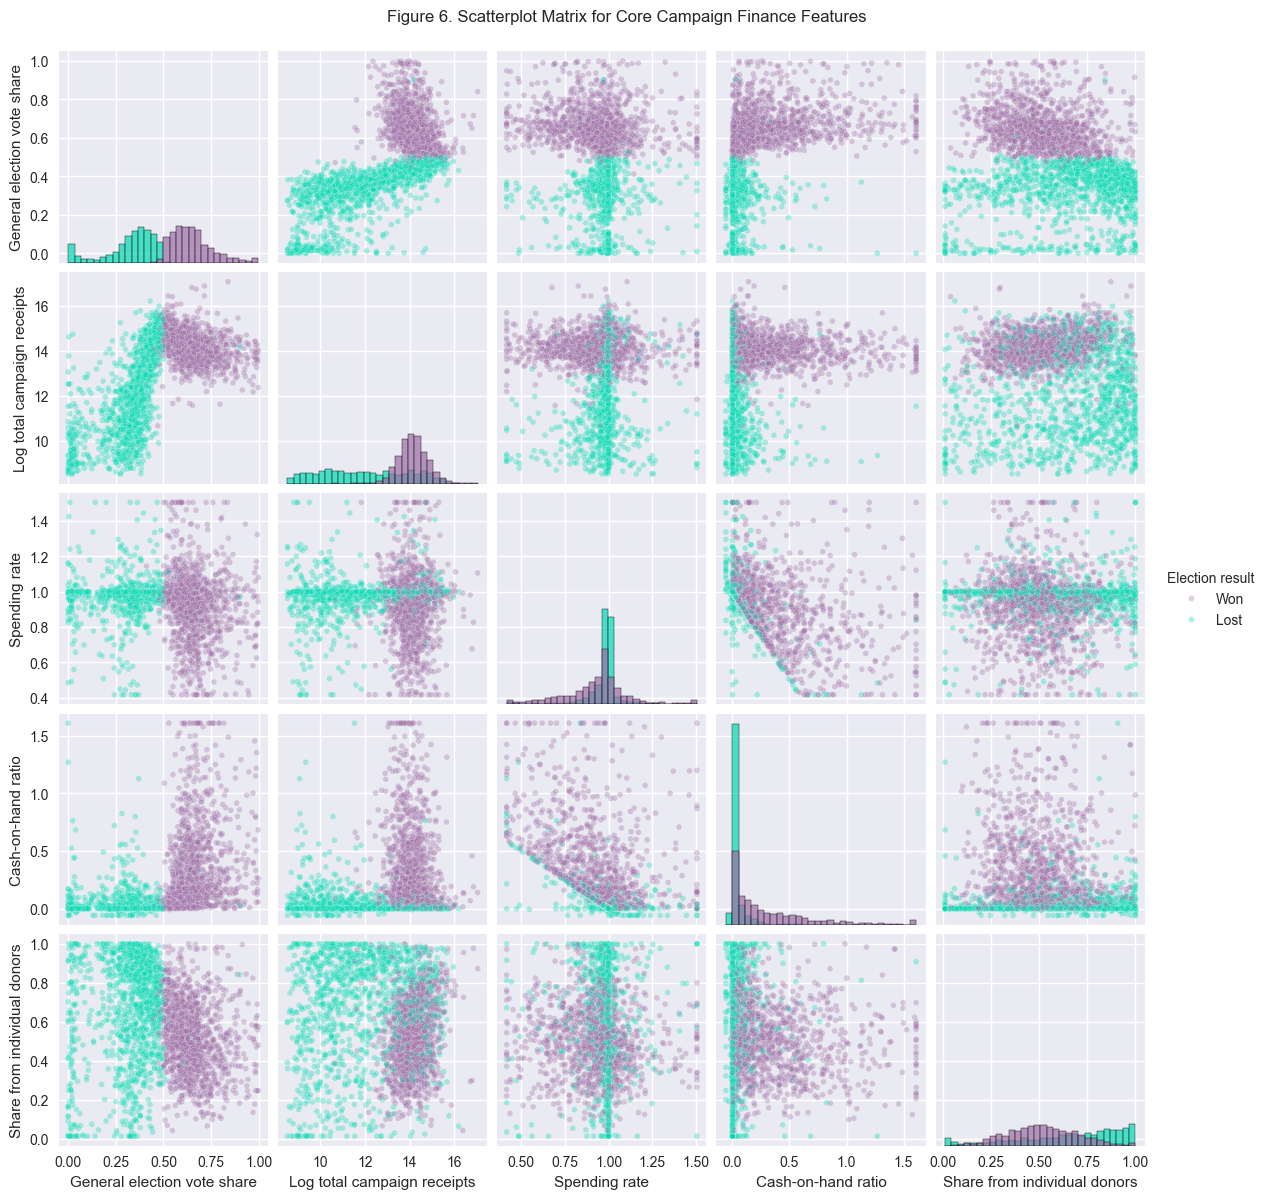

In [13]:
pair_df = house[['vote_share', 'log1p_ttl_receipts', 'burn_rate', 'cash_ratio', 'indiv_share', 'outcome']].dropna().copy()
if len(pair_df) > 2500:
    pair_df = pair_df.sample(2500, random_state=577)

pair_df['Election result'] = pair_df['outcome'].map({0: 'Lost', 1: 'Won'})
pair_df = pair_df.rename(columns={
    'vote_share': 'General election vote share',
    'log1p_ttl_receipts': 'Log total campaign receipts',
    'burn_rate': 'Spending rate',
    'cash_ratio': 'Cash-on-hand ratio',
    'indiv_share': 'Share from individual donors'}).drop(columns='outcome')

g = sns.pairplot( pair_df, hue='Election result', diag_kind='hist', palette=['#9c6da5', '#04d8b2'], plot_kws={'alpha': 0.32, 's': 18}, diag_kws={'bins': 30, 'alpha': 0.7}, height=2.35 )

g.figure.suptitle('Figure 6. Scatterplot Matrix for Core Campaign Finance Features', y=1.02)
plt.show()

__Figure 6__ The scatterplot matrix on several key features reveals several clear pattern: The strongest and most orderly relationship is between **general election vote share** and **log total campaign receipts**. Candidates with larger receipt totals tend, on the average, to receive a larger share of the vote, and the distributions also show a visible shift in receipts between winners and losers. At an elementary descriptive level, campaign scale appears to be the single clearest financial correlate of electoral performance in the present sample.

However, it should be noted that panels involving **vote share** and **election result** are largely tautological, since outcome is entirely determined by vote share in a first-past-the-post contest. Likewise, some of the more striking relationships among the engineered finance variables, especially those involving **spending rate (or burn rate)** and **cash-on-hand ratio**, likely reflect accounting structure in addition to any underlying political phenomenon. These variables are constructed from related financial quantities, so strong geometric patterns between them may indicate partial algebraic dependence rather than genuinely distinct dimensions of campaign behavior.

The matrix also suggests that some variables may be more informative than others. **Log total campaign receipts** appears to contain substantial signal, while variables such as **share from individual donors** exhibit more diffuse and less obviously monotone relationships with electoral performance. This does not necessarily imply that these features are unimportant, but it does suggest that they may be acting via more complicated mechanisms or may be proxies for candidate type, strategy, or race context rather than exerting a simple direct effect on vote share.

Overall, the matrix supports two preliminary conclusions: First, campaign finance variables do appear to carry meaningful information about electoral outcomes, especially measures of overall campaign scale. Second, several engineered ratios display strong internal structure that warrants caution in later modeling, since they may be partially redundant or mechanically related. This argues for proceeding with a parsimonious initial regression specification before moving to broader multivariate or machine learning models.

In [ ]:
reg_df = house[['vote_share', 'log1p_ttl_receipts', 'incumbency', 'party']].dropna().copy()
reg_df['party_group'] = np.where(reg_df['party'].isin(['DEM', 'REP']), reg_df['party'], 'OTH')
reg_df['incumbency_status'] = reg_df['incumbency'].map({'C': 'Challenger', 'I': 'Incumbent', 'O': 'Open-seat'})

X = pd.concat([
    reg_df[['log1p_ttl_receipts']].astype(float),
    pd.get_dummies(reg_df['incumbency_status'], prefix='inc', dtype=float).drop(columns='inc_Challenger'),
    pd.get_dummies(reg_df['party_group'], prefix='pty', dtype=float).drop(columns='pty_OTH')
], axis=1)

X = sm.add_constant(X)
y = reg_df['vote_share'].astype(float)

model1 = sm.OLS(y, X).fit(cov_type='HC3')

term_labels = {
    'const': 'Intercept',
    'log1p_ttl_receipts': 'ln(1 + total receipts)',
    'inc_Incumbent': 'Incumbent',
    'inc_Open-seat': 'Open seat contender',
    'pty_DEM': 'Democrat',
    'pty_REP': 'Republican'
}

reg_table = pd.DataFrame({
    'Term': [term_labels.get(term, term) for term in model1.params.index],
    'Coefficient': model1.params.values,
    'Robust SE': model1.bse.values,
    'z': model1.tvalues.values,
    'p-value': model1.pvalues.values})

reg_table['Coefficient'] = reg_table['Coefficient'].map(lambda x: f'{x:.4f}')
reg_table['Robust SE'] = reg_table['Robust SE'].map(lambda x: f'({x:.4f})')
reg_table['z'] = reg_table['z'].map(lambda x: f'{x:.2f}')
reg_table['p-value'] = reg_table['p-value'].map(lambda x: '<0.001' if x < 0.001 else f'{x:.3f}')

model_stats = pd.DataFrame({
    'Term': ['N', 'R²', 'Adj. R²'],
    'Coefficient': [f'{int(model1.nobs):,}', f'{model1.rsquared:.3f}', f'{model1.rsquared_adj:.3f}'],
    'Robust SE': ['', '', ''],
    'z': ['', '', ''],
    'p-value': ['', '', '']})

reg_table = pd.concat([reg_table, model_stats], ignore_index=True)

print('Table 4. Baseline OLS Regression of Vote Share')
display(reg_table)
print('Reference categories: Challenger and OTH. Robust standard errors are HC3.')
reg_table.to_csv('Table 4.csv')

Table 4. Baseline OLS Regression of Vote Share


,Term,Coefficient,Robust SE,z,p-value
0,Intercept,-0.2297,(0.0095),-24.20,<0.001
1,ln(1 + total receipts),0.0318,(0.0009),33.83,<0.001
2,Incumbent,0.2291,(0.0033),70.47,<0.001
3,Open seat contender,0.0520,(0.0050),10.42,<0.001
4,Democrat,0.2248,(0.0062),36.47,<0.001
5,Republican,0.1977,(0.0062),31.75,<0.001
6,N,"8,129",,,
7,R²,0.704,,,
8,Adj. R²,0.704,,,


Reference categories: Challenger and OTH. Robust standard errors are HC3.


__Table 4__ reports a baseline OLS regression of general election vote share on log total receipts, incumbency, and party affiliation using HC3 heteroskedasticity-robust standard errors. The results indicate that campaign scale remains a strong positive correlate of electoral performance even after controlling for major structural predictors. In paricular, a single unit increase in `ln(1 + total receipts)` is associated with a 0.0318 increase in vote share, implying that a doubling of campaign receipts corresponds to roughly a 2.2 percentage point increase in expected vote share (a highly nontrivial increment in close races).

Importantly, incumbency is very strongly associated with electoral performance. Relative to challengers, incumbents receive substantially higher predicted vote share, while open seat contenders also outperform challengers by a smaller but nevertheless meaningful margin. Party effects are likewise large: Democratic and Republican candidates both consistently outperform third party candidates, reflecting the dominant position of the two ruling parties in U.S. federal general elections.

Overall, the model explains a large share of the variation in vote share (R² = 0.704), suggesting that campaign scale, incumbency, and party together provide a strong baseline account of electoral outcomes in the present dataset.